In [1]:
library(Signac)
library(dittoSeq)
library(Seurat)
library(gridExtra)
library(GenomicRanges)
library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)
library(dplyr)
library(future)

plan("multicore", workers = 32)
options(future.globals.maxSize = 100000 * 1024^5)

set.seed(1234)

Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:gridExtra’:

    combine


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, s

In [2]:
suppressPackageStartupMessages({
    library(here)
    library(tibble)
    library(dittoSeq)
    library(stringr)
    library(data.table)
    library(tidyverse)
})


In [3]:
sessionInfo()

R version 4.3.2 (2023-10-31)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.4 (Plow)

Matrix products: default
BLAS/LAPACK: /gpfs/home3/cruiz2/miniconda3/envs/r_env_standr/lib/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Amsterdam
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] lubridate_1.9.3                   forcats_1.0.0                    
 [3] purrr_1.0.2                       readr_2.1.5                      
 [5] tidyr_1.3.1                

In [4]:
obj.multi <- readRDS('mannens_multiome.rds')
obj.multi

An object of class Seurat 
429676 features across 166785 samples within 2 assays 
Active assay: RNA (18813 features, 0 variable features)
 1 layer present: counts
 1 other assay present: ATAC

In [5]:
atac_multiome <- readRDS('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/Mannens2024/Pool_peaks_multiome.rds')
atac_multiome

An object of class Seurat 
410863 features across 166785 samples within 1 assay 
Active assay: ATAC (410863 features, 0 variable features)
 2 layers present: counts, data
 19 dimensional reductions calculated: Embedding, LSI, LSI_b, LSI_main, TSNE, TSNE_1, TSNE_10, TSNE_2, TSNE_3, TSNE_4, TSNE_5, TSNE_bin, TSNE_main, TSNE_old, UMAP, UMAP3D, UMAP3D_main, UMAP_main, umap

In [6]:
meta <- atac_multiome@meta.data

rownames(meta) <- paste0(rownames(meta), '-1')

meta

,Age,Agetext,Ageunit,All_fc_analysis_id,Analysis,Chemistry,Class,ClusterName,Clusters,Clusters_main,⋯,lowmapq,mitochondrial,passed_filters,peak_region_cutsites,peak_region_fragments,preClusters,regions,total,unmapped,Coarse
,<dbl>,<fct>,<fct>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>
10X280_1:ACGCCACAGGTAACGA-1,7.6,7.6w,pcw,6962,Queueing,multiome_atac,Neuron,Neur_Purk_2,0,13,⋯,5969,2,26759,22102,12149,2,Cerebellum,50761,376,Neuron_Purk
10X280_1:CAGGAAGGTTAACGAT-1,7.6,7.6w,pcw,6962,Queueing,multiome_atac,Neuron,Neur_Purk_2,0,13,⋯,2585,0,12859,12416,6654,2,Cerebellum,25720,200,Neuron_Purk
10X406_1:TACGTACAGTGACCTG-1,9.5,9.5w,pcw,6992,Queueing,multiome_atac,Neuron,Neur_Purk_2,0,13,⋯,4200,6,27965,14419,7991,9,Cerebellum,42467,255,Neuron_Purk
10X280_1:ATTGGTTCATTGACAT-1,7.6,7.6w,pcw,6962,Queueing,multiome_atac,Neuron,Neur_Purk_2,0,13,⋯,7057,0,31168,28049,15257,2,Cerebellum,64221,435,Neuron_Purk
10X280_1:ATTGGCTAGTACTGGT-1,7.6,7.6w,pcw,6962,Queueing,multiome_atac,Neuron,Neur_Purk_2,0,13,⋯,5888,0,32100,27178,14788,4,Cerebellum,64099,406,Neuron_Purk
10X280_1:CAGATTCAGCAGCTCA-1,7.6,7.6w,pcw,6962,Queueing,multiome_atac,Neuron,Neur_Purk_2,0,13,⋯,6413,0,24171,23871,12808,4,Cerebellum,49770,277,Neuron_Purk
10X280_1:ACGGTACGTGTAATAC-1,7.6,7.6w,pcw,6962,Queueing,multiome_atac,Neuron,Neur_Purk_2,0,13,⋯,2953,2,14631,14577,7816,4,Cerebellum,28994,206,Neuron_Purk
10X365_2:ACCAATATCAATGACC-1,9.5,9.5w,pcw,6977,Queueing,multiome_atac,Neuron,Neur_Purk_2,0,13,⋯,4087,0,15654,17134,9200,14,Cerebellum,45068,500,Neuron_Purk
10X280_1:ACCTACCTCGCTAGTG-1,7.6,7.6w,pcw,6962,Queueing,multiome_atac,Neuron,Neur_Purk_2,0,13,⋯,4811,0,23133,21832,11828,2,Cerebellum,45438,284,Neuron_Purk


In [7]:
obj.multi@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ATAC,nFeature_ATAC
,<fct>,<dbl>,<int>,<dbl>,<int>
10X280_1:ACGCCACAGGTAACGA-1,10X280,3642,1888,9827,9827
10X280_1:CAGGAAGGTTAACGAT-1,10X280,4075,2032,5550,5550
10X406_1:TACGTACAGTGACCTG-1,10X406,3436,1674,8216,8216
10X280_1:ATTGGTTCATTGACAT-1,10X280,6070,2494,11593,11593
10X280_1:ATTGGCTAGTACTGGT-1,10X280,2707,1559,11456,11456
10X280_1:CAGATTCAGCAGCTCA-1,10X280,5334,2378,9663,9663
10X280_1:ACGGTACGTGTAATAC-1,10X280,3602,1816,6328,6328
10X365_2:ACCAATATCAATGACC-1,10X365,3994,1774,7405,7405
10X280_1:ACCTACCTCGCTAGTG-1,10X280,4560,2098,9106,9106


In [8]:
obj.multi <- AddMetaData(obj.multi, meta)

In [9]:
obj.multi@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ATAC,nFeature_ATAC,Age,Agetext,Ageunit,All_fc_analysis_id,Analysis,⋯,lowmapq,mitochondrial,passed_filters,peak_region_cutsites,peak_region_fragments,preClusters,regions,total,unmapped,Coarse
,<fct>,<dbl>,<int>,<dbl>,<int>,<dbl>,<fct>,<fct>,<dbl>,<fct>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>
10X280_1:ACGCCACAGGTAACGA-1,10X280,3642,1888,9827,9827,7.6,7.6w,pcw,6962,Queueing,⋯,5969,2,26759,22102,12149,2,Cerebellum,50761,376,Neuron_Purk
10X280_1:CAGGAAGGTTAACGAT-1,10X280,4075,2032,5550,5550,7.6,7.6w,pcw,6962,Queueing,⋯,2585,0,12859,12416,6654,2,Cerebellum,25720,200,Neuron_Purk
10X406_1:TACGTACAGTGACCTG-1,10X406,3436,1674,8216,8216,9.5,9.5w,pcw,6992,Queueing,⋯,4200,6,27965,14419,7991,9,Cerebellum,42467,255,Neuron_Purk
10X280_1:ATTGGTTCATTGACAT-1,10X280,6070,2494,11593,11593,7.6,7.6w,pcw,6962,Queueing,⋯,7057,0,31168,28049,15257,2,Cerebellum,64221,435,Neuron_Purk
10X280_1:ATTGGCTAGTACTGGT-1,10X280,2707,1559,11456,11456,7.6,7.6w,pcw,6962,Queueing,⋯,5888,0,32100,27178,14788,4,Cerebellum,64099,406,Neuron_Purk
10X280_1:CAGATTCAGCAGCTCA-1,10X280,5334,2378,9663,9663,7.6,7.6w,pcw,6962,Queueing,⋯,6413,0,24171,23871,12808,4,Cerebellum,49770,277,Neuron_Purk
10X280_1:ACGGTACGTGTAATAC-1,10X280,3602,1816,6328,6328,7.6,7.6w,pcw,6962,Queueing,⋯,2953,2,14631,14577,7816,4,Cerebellum,28994,206,Neuron_Purk
10X365_2:ACCAATATCAATGACC-1,10X365,3994,1774,7405,7405,9.5,9.5w,pcw,6977,Queueing,⋯,4087,0,15654,17134,9200,14,Cerebellum,45068,500,Neuron_Purk
10X280_1:ACCTACCTCGCTAGTG-1,10X280,4560,2098,9106,9106,7.6,7.6w,pcw,6962,Queueing,⋯,4811,0,23133,21832,11828,2,Cerebellum,45438,284,Neuron_Purk


In [10]:
table(obj.multi$Coarse)


        COP Endothelial Floor_plate   Glioblast         IPC    Lymphoid 
        358        5139        2958       41345        2535         108 
  Microglia       Mural      Neuron   Neuron_CB   Neuron_DA  Neuron_DRG 
      10374        9385        3060        8910         578         449 
Neuron_GABA  Neuron_Gly   Neuron_HB  Neuron_Int   Neuron_MB Neuron_Purk 
        897        3195        8435        4586        8621       15088 
 Neuron_Tel         OPC         PVM      PreOPC          RG  Roof_plate 
      10158        1586         363        3943       20655        2843 
    Schwann 
       1216 

In [11]:
max_cells_per_celltype = 500

sampled.metadata <- obj.multi@meta.data %>%
      rownames_to_column(., 'barcode2') %>%
      group_by(., Coarse) %>% 
      nest() %>%            
      mutate(n =  map_dbl(data, nrow)) %>%
      mutate(n = min(n, max_cells_per_celltype)) %>%
      ungroup() %>% 
      mutate(samp = map2(data, n, sample_n)) %>% 
      select(-data) %>%
      unnest(samp)

obj.multi <- subset(obj.multi, cells = sampled.metadata$barcode2)
obj.multi

An object of class Seurat 
429676 features across 11778 samples within 2 assays 
Active assay: RNA (18813 features, 0 variable features)
 1 layer present: counts
 1 other assay present: ATAC

In [12]:
table(obj.multi$Coarse)


        COP Endothelial Floor_plate   Glioblast         IPC    Lymphoid 
        358         500         500         500         500         108 
  Microglia       Mural      Neuron   Neuron_CB   Neuron_DA  Neuron_DRG 
        500         500         500         500         500         449 
Neuron_GABA  Neuron_Gly   Neuron_HB  Neuron_Int   Neuron_MB Neuron_Purk 
        500         500         500         500         500         500 
 Neuron_Tel         OPC         PVM      PreOPC          RG  Roof_plate 
        500         500         363         500         500         500 
    Schwann 
        500 

## Load and setup the 10x scATAC-seq query

In [13]:
obj.atac <- readRDS('dmg_atac.rds')
obj.atac

An object of class Seurat 
788632 features across 124594 samples within 2 assays 
Active assay: ATAC (410863 features, 410863 variable features)
 2 layers present: counts, data
 1 other assay present: peak.orig
 1 dimensional reduction calculated: lsi

In [14]:
obj.atac <- subset(obj.atac, cells = sample(Cells(obj.atac), 1000))

In [15]:
obj.atac

An object of class Seurat 
788632 features across 1000 samples within 2 assays 
Active assay: ATAC (410863 features, 410863 variable features)
 2 layers present: counts, data
 1 other assay present: peak.orig
 1 dimensional reduction calculated: lsi

In [16]:
obj.atac@meta.data

,orig.ident,nCount_ATAC,nFeature_ATAC,nCount_peak.orig,nFeature_peak.orig
,<fct>,<dbl>,<int>,<dbl>,<int>
GNG_region_11_AAAGCTTGTGGAAACG-1,GNG,773,764,1379,1353
GNG_region_11_AACGCCCAGGAGCAAC-1,GNG,11489,10652,19329,17417
GNG_region_11_AAGGATTAGAACCTGT-1,GNG,2630,2472,3889,3585
GNG_region_11_ACGGTTAGTGCTAGCG-1,GNG,5944,5517,9016,8085
GNG_region_11_ACTAAAGCACAAAGGT-1,GNG,3528,3366,6119,5714
GNG_region_11_AGCCTCCGTGAAGCCT-1,GNG,3402,3181,4997,4591
GNG_region_11_ATGGTTATCCTAATTC-1,GNG,10411,9350,15623,13482
GNG_region_11_CAACAGGCAATTAACC-1,GNG,11004,10157,17722,15832
GNG_region_11_CCCTCACCAAGGCCAA-1,GNG,3226,3099,5966,5585


## Load and setup the rna Ref

In [17]:
obj.rna <- readRDS('/projects/0/einf2548/cruiz/dmg/data/references/Braun2023/subset_fetal_brain_atlas_all_genes.rds')
obj.rna

An object of class Seurat 
18675 features across 499781 samples within 1 assay 
Active assay: RNA (18675 features, 0 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: umap

In [18]:
table(obj.rna$PrevClusters)


   0   10   11   12   13   14   15   16   17   19   20   21   22   23   24   25 
 741  729 3701 2827 1748 1093 1833 2497  502 1499 1867  518  521 1315  799  499 
  26   27   28   29   31   32   33   34   35   36   37   38   39   40   41   42 
  42  201  793  682 1520  556 1270  665  768 1062  950 1494  658 1065    3   38 
  43   44   45   46   47   48   49   50   51   52   53   54   55   56   57   58 
  35   50   48   20   36    8   31  276  483  139 1134  672 1059  450  365  393 
  59   60   61   62   63   64   65   66   67   68   69   70   71   72   74   75 
1244  332  528  522  279 1129  332  504  722  451  637  368  233  482  799 1923 
  76   77   78   79   80   81   83   85   87   88   89   90   91   92   93   94 
2093  713  545 2273 1292  637  521  496  690  431  603  736  371  329  915  308 
  95   96   97   98   99  100  101  102  103  105  106  107  108  109  110  111 
 412  920 1715  369  207 1714 1353 1665  890  598 1197  600   59   84  281  365 
 112  113  114  115  116  1

In [19]:
detailed_meta <- as.data.frame(data.table::fread('/projects/0/einf2548/cruiz/dmg/data/references/Braun2023/detailed_annotation_Mossi.csv')) %>% rename('PrevClusters'='PrevCluster')
detailed_meta

V1,ClusterID,CellClass,AnnotationName,AnnotationDescription,AnnotationDefinition,PrevClusters,batch
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
0-0,0,Glioblast,RGL,Radial glia (RGL; +HES1),+HES1,507,0
1-0,1,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,506,0
2-0,2,Pre-astrocyte,PREAC,Pre-astrocyte (PREAC; +BCAN +TNC +AQP4),+BCAN +TNC +AQP4,515,0
3-0,3,Pre-astrocyte,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,516,0
4-0,4,Glioblast,GBL,Glioblast (GBL; +BCAN +TNC),+BCAN +TNC,517,0
5-0,5,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,518,0
6-0,6,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,513,0
7-0,7,Pre-astrocyte,O-HEM,Cortical Hem (O-HEM; +CRYAB +RSPO2),+CRYAB +RSPO2,512,0
8-0,8,Pre-astrocyte,GBL,Glioblast (GBL; +BCAN +TNC),+BCAN +TNC,467,0


In [20]:
meta <- obj.rna@meta.data %>%
  left_join(detailed_meta, by = "PrevClusters")
meta

barcode,CellClass.x,CellCycle,Clusters,Donor,MitoFraction,NGenes,PrevClusters,SampleID,Sex,⋯,TotalUMIs,Age,Region,V1,ClusterID,CellClass.y,AnnotationName,AnnotationDescription,AnnotationDefinition,batch
<chr>,<fct>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,⋯,<dbl>,<dbl>,<fct>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>
10X156_5:CTCATTAAGCGTGTCC,Radial glia,0.0020885547,127,XDD:334,0.004177109,2419,561,10X156_5,,⋯,4788,8.0,Midbrain,102-1,102,Radial glia,S-CC,Cell cycle (S-CC; +TOP2A),+TOP2A,1
10X254_5:GCCAGCAGTGGCTTGC,Glioblast,0.0094677582,18,XDD:385,0.064355172,3698,506,10X254_5,,⋯,7816,14.0,Diencephalon,1-0,1,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,0
10X112_1:CAAGTTGCAACACCCG,Neuronal IPC,0.0125599448,69,XHU:305,0.014386847,1919,11,10X112_1,,⋯,4379,7.5,Forebrain,21-3,21,Neuronal IPC,NBL,Neuroblast (NBL; +NHLH1),+NHLH1,3
10X288_1:CGCAGGTAGTGGCGAT,Neuron,0.0011734189,406,XDD:395,0.019948123,5114,150,10X288_1,,⋯,16192,6.0,Brain,71-4,71,Neuron,NT-VGLUT2,Glutamatergic 2 (NT-VGLUT2; +SLC17A6),+SLC17A6,4
10X288_6:GTGTGATGTTAGTCGT,Radial glia,0.0088906502,124,XDD:395,0.027974404,5882,564,10X288_6,,⋯,17659,6.0,Brain,99-1,99,Radial glia,RGL,Radial glia (RGL; +HES1),+HES1,1
10X188_3:TGTTTGTAGATTGGGC,Radial glia,0.0408066995,177,XDD:351,0.028541101,3709,390,10X188_3,,⋯,8479,12.0,Telencephalon,6-1,6,Radial glia,S-G2M,Cell cycle G2/M phase (S-G2M; +TOP2A +PLK1),+TOP2A +PLK1,1
10X102_2:AGCGTCGGTTAAAGAC,Neuroblast,0.0013852548,296,XHU:297,0.012929044,2540,356,10X102_2,,⋯,6497,10.0,Telencephalon,9-2,9,Neuroblast,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,2
10X112_2:CAGATCAAGCTCCTCT,Radial glia,0.0050801095,165,XHU:305,0.011918718,2456,372,10X112_2,,⋯,5118,7.5,Forebrain,16-1,16,Radial glia,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,1
10X99_5:CAGCTAAGTCCATGAT,Neuron,0.0010366275,585,BRC2021,0.004837595,1584,20,10X99_5,,⋯,2894,8.0,Diencephalon,78-4,78,Neuron,NEUR,Neuron (NEUR; +INA),+INA,4


In [21]:
obj.rna$DetailedCellClass <- meta$CellClass.y

In [22]:
obj.rna$DetailedCellClass <- recode(obj.rna$DetailedCellClass,
                                     'Failed'='COP')

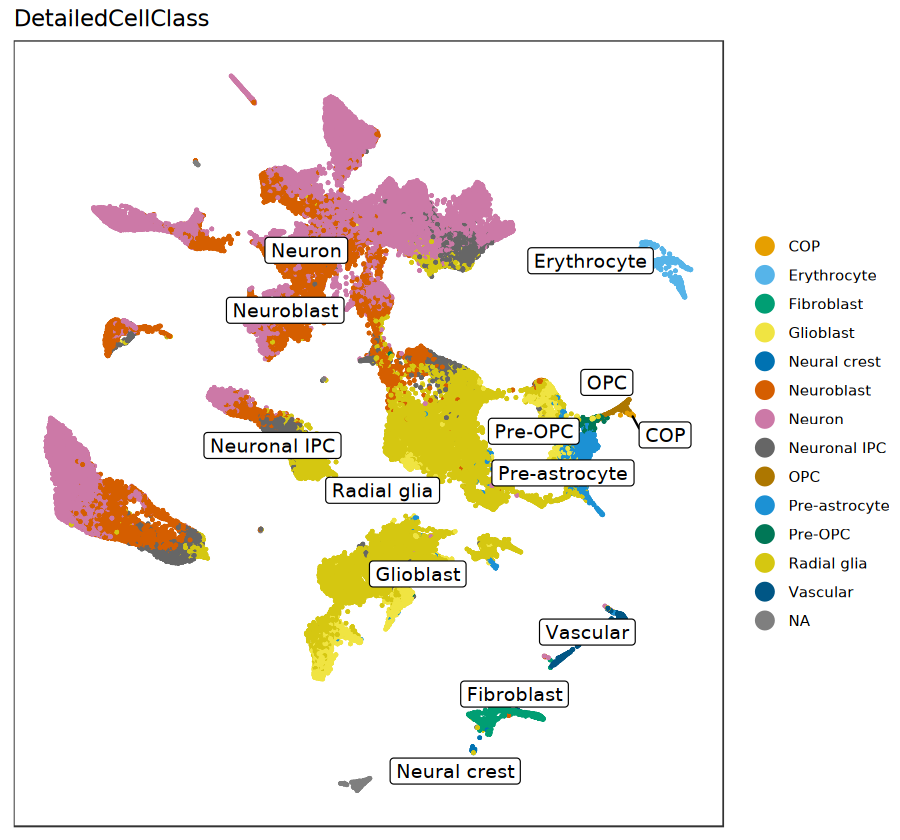

In [23]:
options(repr.plot.height = 7, repr.plot.width = 7.5)
dittoDimPlot(subset(obj.rna, cells = sample(Cells(obj.rna), 100000)),
             reduction.use = "umap", var = "DetailedCellClass", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

In [24]:
table(obj.rna$DetailedCellClass)


          COP   Erythrocyte    Fibroblast     Glioblast  Neural crest 
          207          2677          5737         28094           264 
   Neuroblast        Neuron  Neuronal IPC           OPC Pre-astrocyte 
        85476        168852         33361          1637          9776 
      Pre-OPC   Radial glia      Vascular 
         1576        155937          3426 

In [25]:
obj.rna@meta.data <- obj.rna@meta.data %>%
  mutate(DetailedCellClass = ifelse(is.na(DetailedCellClass), 'NA', as.character(DetailedCellClass)))

In [26]:
obj.rna <- subset(obj.rna, DetailedCellClass == 'NA', invert = TRUE)
obj.rna

An object of class Seurat 
18675 features across 497020 samples within 1 assay 
Active assay: RNA (18675 features, 0 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: umap

In [27]:
max_cells_per_celltype = 500

sampled.metadata <- obj.rna@meta.data %>%
      rownames_to_column(., 'barcode2') %>%
      group_by(., DetailedCellClass) %>% 
      nest() %>%            
      mutate(n =  map_dbl(data, nrow)) %>%
      mutate(n = min(n, max_cells_per_celltype)) %>%
      ungroup() %>% 
      mutate(samp = map2(data, n, sample_n)) %>% 
      select(-data) %>%
      unnest(samp)

obj.rna <- subset(obj.rna, cells = sampled.metadata$barcode2)
obj.rna

An object of class Seurat 
18675 features across 5971 samples within 1 assay 
Active assay: RNA (18675 features, 0 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: umap

In [28]:
table(obj.rna$DetailedCellClass)


          COP   Erythrocyte    Fibroblast     Glioblast  Neural crest 
          207           500           500           500           264 
   Neuroblast        Neuron  Neuronal IPC           OPC Pre-astrocyte 
          500           500           500           500           500 
      Pre-OPC   Radial glia      Vascular 
          500           500           500 

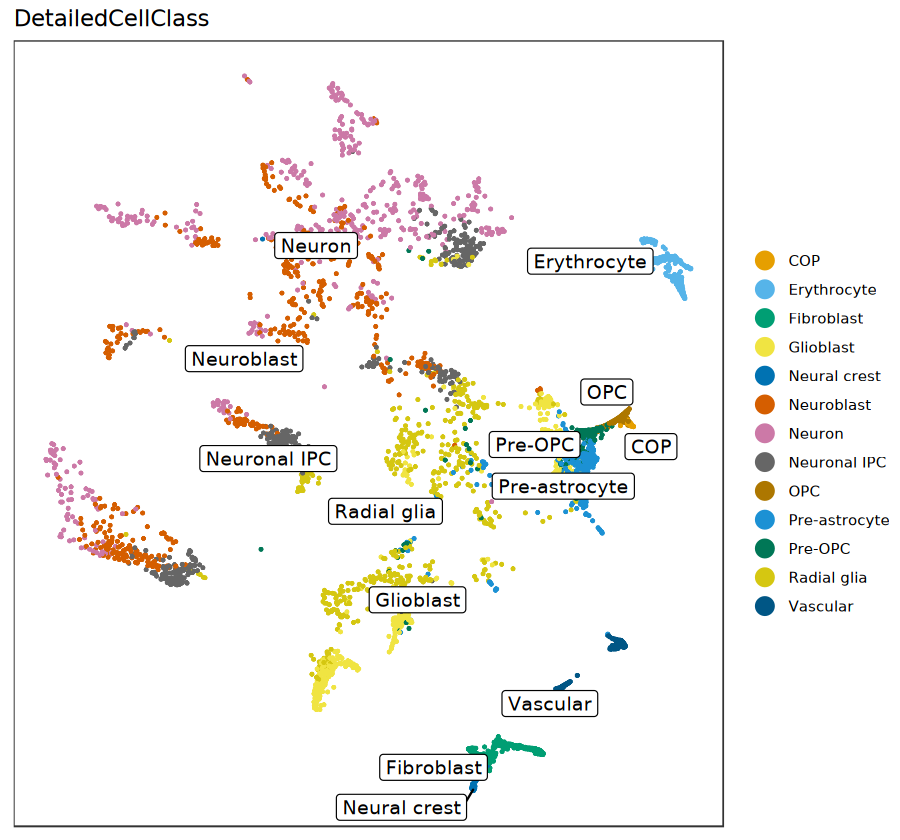

In [29]:
options(repr.plot.height = 7, repr.plot.width = 7.5)
dittoDimPlot(obj.rna,
             reduction.use = "umap", var = "DetailedCellClass", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

## Preprocessing/normalization for all datasets

In [31]:
embedding <- Embeddings(obj.rna, reduction = 'umap')

In [32]:
all(rownames(obj.rna@reductions$umap@cell.embeddings) == rownames(embedding))

[1] TRUE

In [39]:
obj.rna <- obj.rna %>% NormalizeData()%>%FindVariableFeatures()%>%ScaleData()%>%RunPCA()%>%
  RunUMAP(dims = 1:30, return.model = TRUE)

Centering and scaling data matrix

PC_ 1 
Positive:  ARHGAP29, FN1, IGFBP7, COBLL1, COL4A1, IFITM3, ENG, ADGRF5, FLT1, EGFL7 
	   ESAM, GNG11, FOXQ1, EPAS1, HLA-E, DLC1, COL4A2, KLF2, SLC9A3R2, ETS1 
	   GALNT18, FOXF2, A2M, ITM2A, C1orf54, MYH9, IFITM2, ADORA2A, ADGRL4, CLDN5 
Negative:  CTNNA2, CADM2, DCC, NRXN1, GRID2, ERBB4, HES6, STMN2, TENM2, FABP7 
	   ANKS1B, DPP6, FRMD5, PLPPR1, LRRC4C, GRIA4, MEIS2, KCNH7, CSMD1, PPP2R2B 
	   SOX6, PTPRO, DPP10, ASCL1, IGFBPL1, GRIA2, NCKAP5, DSCAM, GRIK2, PCDH9 
PC_ 2 
Positive:  COL1A2, COL3A1, EDNRA, OLFML3, LGALS1, PCOLCE, DCN, PDGFRB, PCDH18, FRZB 
	   PLAC9, LUM, CD248, MYOF, TPM2, PLXDC1, COLEC12, COL18A1, BGN, IGF2 
	   ITIH5, NDUFA4L2, S100A11, RGS5, TBX18, TBX2, LAMC3, FOXD1, CCDC3, DDR2 
Negative:  SOX18, PECAM1, SLCO2B1, CLDN5, SLC7A5, CDH5, KDR, MYCT1, CD93, CLEC3B 
	   SLC38A5, PTPRB, DIPK2B, CD34, TIE1, MFSD2A, TM4SF18, ADGRL4, ICAM2, INPP5D 
	   EDN1, SRARP, ROBO4, PDGFB, VWF, SRGN, ST8SIA6, SLC7A1, ATP10A, ZNF366 
PC_ 3 
Posi

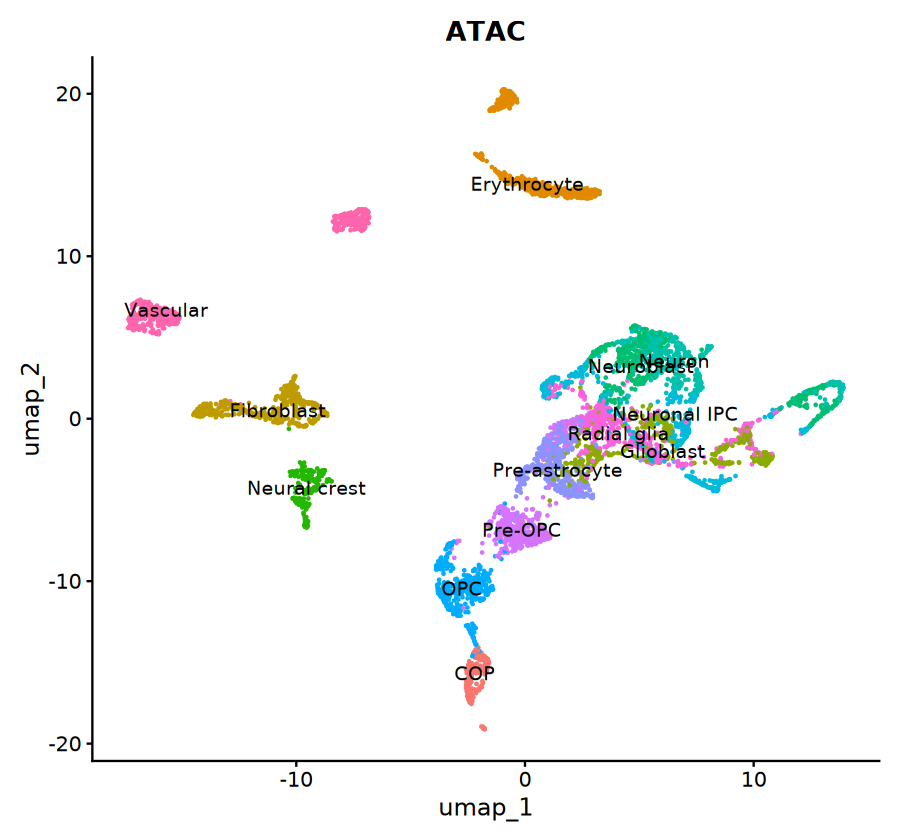

In [40]:
DimPlot(
  obj.rna, group.by = "DetailedCellClass",
  reduction = "umap", label = TRUE
) + ggtitle("ATAC") + NoLegend()

In [41]:
obj.rna@reductions$umap@cell.embeddings

,umap_1,umap_2
10X101_2:CTCTACGCACCACCAG,9.6942260,-1.23942251
10X110_5:CAGAGAGTCGGTGTTA,-0.6284371,20.13118535
10X252_5:TGCAGTACAGCTGTGC,1.8166175,-4.45672912
10X164_1:CTATCTAAGTGGTGAC,5.3226153,2.52708333
10X102_4:GGAGCAATCTGTCCGT,9.6122920,-0.61316258
10X185_4:TGCAGGCAGAAATTGC,-0.1602736,14.85100918
10X181_3:TTGTTGTTCGGAATGG,-9.2108310,-3.86277456
10X213_1:TTCCACGGTTCAACGT,-2.5897813,-10.37264461
10X187_1:GTATTTCTCTGTCAGA,-3.2082894,-11.69089240
10X186_4:TGAGCGCTCCACTGAA,-0.3355172,14.74826794


In [42]:
obj.rna@reductions$umap@cell.embeddings <- embedding %>% `colnames<-`(c('umap_1', 'umap_2'))

In [43]:
obj.rna@reductions$umap@misc$model$embedding <- embedding  %>% 
                                                    `colnames<-` (NULL)

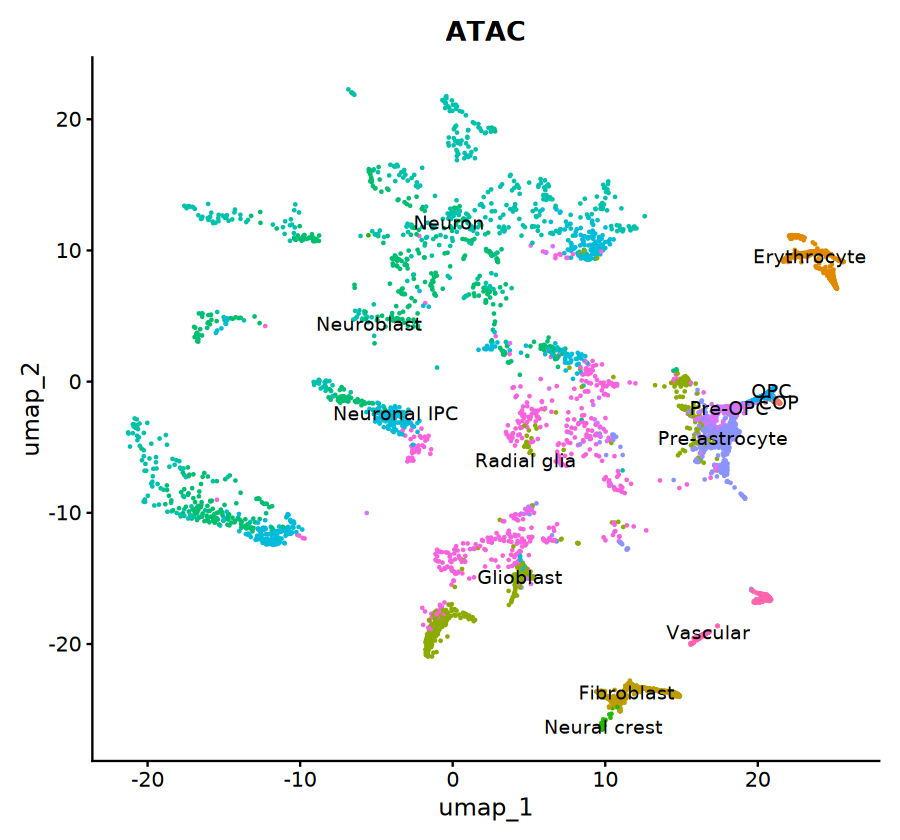

In [44]:
DimPlot(
  obj.rna, group.by = "DetailedCellClass",
  reduction = "umap", label = TRUE
) + ggtitle("ATAC") + NoLegend()

In [45]:
# normalize multiome RNA
DefaultAssay(obj.multi) <- "RNA"
obj.multi <- obj.multi %>% NormalizeData()%>%FindVariableFeatures()%>%ScaleData()%>%RunPCA()
# normalize multiome ATAC
DefaultAssay(obj.multi) <- "ATAC"
obj.multi <- RunTFIDF(obj.multi)
obj.multi <- FindTopFeatures(obj.multi, min.cutoff = "q0")
# Query was already normalized - see signac_dmg_atlas.ipynb

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  FLT1, ADGRF5, EPAS1, PECAM1, SLC7A5, DIPK2B, CGNL1, SLC38A5, ADGRL4, COBLL1 
	   PRKCH, KDR, ARHGAP29, ERG, PDGFB, RASGRP3, ENG, ESAM, CD34, CDH5 
	   MYCT1, EGFL7, CLDN5, IGFBP7, ITM2A, MFSD2A, ETS1, FLI1, FOXQ1, TIE1 
Negative:  ANK2, CADM2, GRIK2, ROBO1, CNTNAP2, STMN2, ATRNL1, NRG1, MAP1B, ELAVL2 
	   PCLO, NEGR1, ERBB4, TUBB3, ELAVL4, DPP10, SLC44A5, FGF14, KHDRBS2, CACNA1B 
	   CSMD1, RBFOX1, DSCAM, GAP43, CSMD3, CNTNAP5, CNTN4, EBF3, TENM3, LRFN5 
PC_ 2 
Positive:  CDH2, MAP1B, SPTBN1, ABLIM1, EBF1, ANK2, GALNT18, PDE10A, CACNA1C, SESTD1 
	   PTPRG, MACROD2, RAPGEF4, RBFOX1, NREP, MYO6, ABCB1, ADGRL2, PRICKLE2, CDH11 
	   CGNL1, SAMD12, CNTNAP2, DIPK2B, KLHL29, ADGRL4, CADM2, SLC7A1, RAPGEF5, KCNB2 
Negative:  DOCK8, SAMSN1, ATP8B4, SYK, CD83, CSF1R, APBB1IP, RBM47, CYBB, NPL 
	   FYB1, DOCK2, SPP1, IKZF1, RUNX1, ADAM28, MERTK, TBXAS1, MAF, HPGDS 
	   SLC9A

## Map scATAC-seq dataset using bridge integration

In [46]:
obj.multi

An object of class Seurat 
429676 features across 11778 samples within 2 assays 
Active assay: ATAC (410863 features, 410863 variable features)
 2 layers present: counts, data
 1 other assay present: RNA
 1 dimensional reduction calculated: pca

In [47]:
obj.rna

An object of class Seurat 
18675 features across 5971 samples within 1 assay 
Active assay: RNA (18675 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: umap, pca

In [48]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,17078846,912.2,24972621,1333.7,24972621,1333.7
Vcells,6446869625,49185.8,17345474646,132335.5,16162706281,123311.7


In [49]:
dims.atac <- 2:50
dims.rna <- 1:50
DefaultAssay(obj.multi) <-  "RNA"
DefaultAssay(obj.rna) <- "RNA"
obj.rna.ext <- PrepareBridgeReference(
  reference = obj.rna, bridge = obj.multi,
  reference.reduction = "pca", reference.dims = dims.rna,
  normalization.method = "LogNormalize")

Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 7047 anchors

Finding integration vectors

Finding integration vector weights

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Warning message:
"Layer counts isn't present in the assay object; returning NULL"

Integrating dataset 2 with reference dataset

Finding integration vectors

Integrating data

Computing nearest neighbor graph

Computing SNN

Generating normalized laplacian graph

Performing eigendecomposition of the normalized laplacian graph

Warning message in PrepDR(object = object, features = features, slot = "data", verbose = verbose):
"The following 6162 features requested have zero variance (running reduction without them): chr10-27319742-27320142, chr10-27344926-27345326, chr10-27345520-27345920, chr10-27347465-27347865, chr10-27349184-27349584, chr10-27354020-27354420, chr10-27354611-27355011, chr10-27360566-27360966, chr10-27365063-27365463, chr10-27383962-2738

In [50]:
bridge.anchor <- FindBridgeTransferAnchors(
  extended.reference = obj.rna.ext, query = obj.atac,
  reduction = "lsiproject", dims = dims.atac)

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 1576 anchors

Finding integration vectors

Finding integration vector weights

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Warning message:
"Layer counts isn't present in the assay object; returning NULL"

Integrating dataset 2 with reference dataset

Finding integration vectors

Integrating data

Finding Transfer anchors

Transform cells to bridge graph laplacian space

Constructing Bridge-cells representation

Warning message:
"UNRELIABLE VALUE: One of the 'future.apply' iterations ('future_lapply-1') unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'f

In [51]:
bridge.anchor

An AnchorSet object containing 8565 anchors between the reference and query Seurat objects. 
 This can be used as input to TransferData.

In [52]:
obj.rna.ext

An object of class Seurat 
429814 features across 17749 samples within 3 assays 
Active assay: RNA (18901 features, 2000 variable features)
 6 layers present: data.1, data.2, counts.1, scale.data.1, counts.2, scale.data.2
 2 other assays present: Bridge, ATAC
 6 dimensional reductions calculated: umap, pca.subset_fetal_brain_atlas_all_genes, pca.SeuratProject, ref.pca, lap, slsi

In [53]:
obj.atac <- MapQuery(
  anchorset = bridge.anchor, reference = obj.rna.ext,
  query = obj.atac,
  refdata = list(
    ct_pred = "DetailedCellClass"),
  reduction.model = "umap")

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Warning message:
"Layer counts isn't present in the assay object; returning NULL"

Integrating dataset 2 with reference dataset

Finding integration vectors

Integrating data

Query and reference dimensions are not equal, proceeding with reference dimensions.

Computing nearest neighbors

Running UMAP projection

14:19:04 Read 1000 rows

14:19:04 Processing block 1 of 1

14:19:04 Commencing smooth kNN distance calibration using 32 threads
 with target n_neighbors = 30

14:19:04 Initializing by weighted average of neighbor coordinates using 32 threads

14:19:04 Commencing optimization for 167 epochs, with 30000 positive edges

14:19:05 Finished



In [54]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,17175807,917.3,24972621,1333.7,24972621,1333.7
Vcells,6646535020,50709.1,17345474646,132335.5,16162706281,123311.7


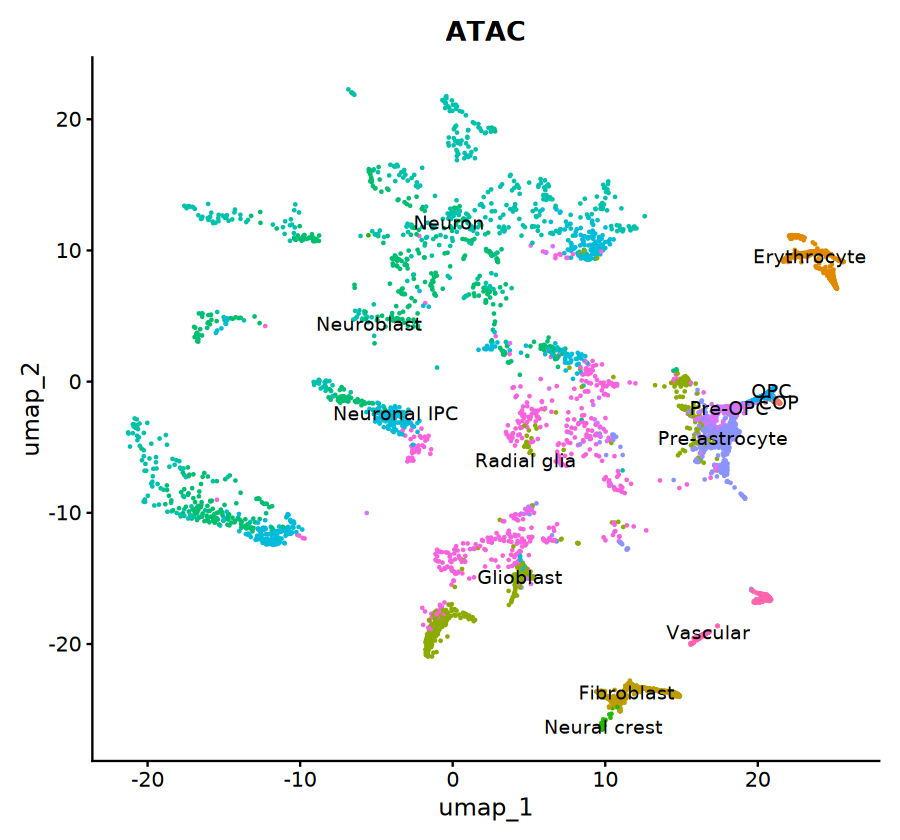

In [55]:
DimPlot(
  obj.rna, group.by = "DetailedCellClass",
  reduction = "umap", label = TRUE
) + ggtitle("ATAC") + NoLegend()

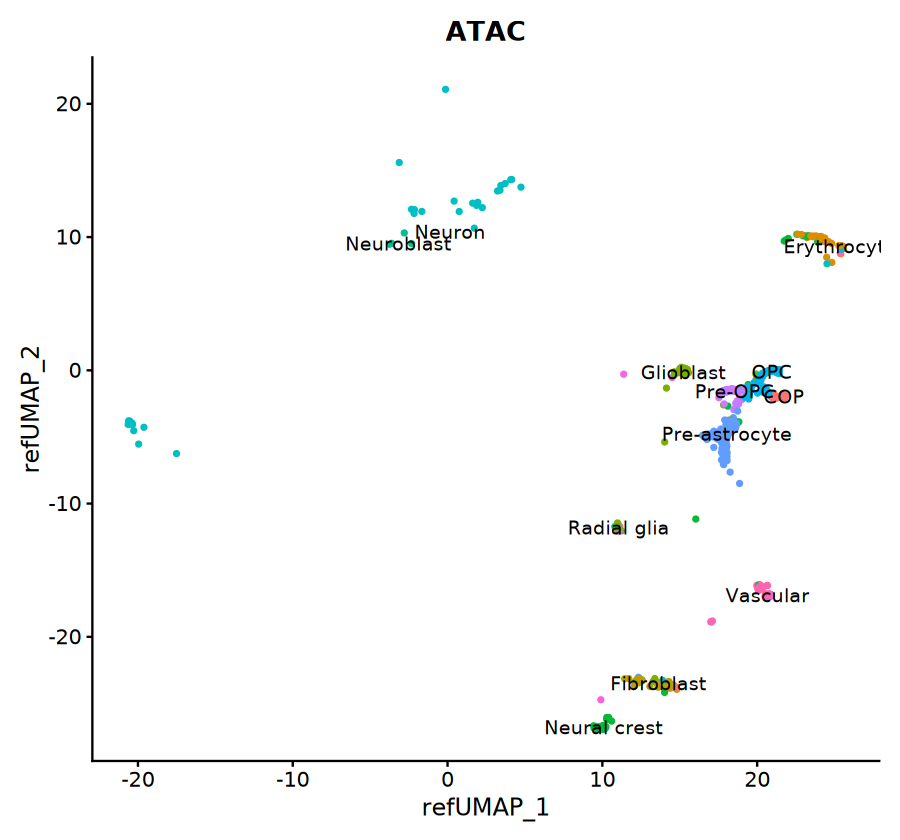

In [56]:
DimPlot(
  obj.atac, group.by = "predicted.ct_pred",
  reduction = "ref.umap", label = TRUE
) + ggtitle("ATAC") + NoLegend()

In [57]:
table(obj.atac$predicted.ct_pred)


          COP   Erythrocyte    Fibroblast     Glioblast  Neural crest 
          152            51            65            56           112 
   Neuroblast        Neuron           OPC Pre-astrocyte       Pre-OPC 
            4            40           205           143            40 
  Radial glia      Vascular 
            9           123 

In [58]:
obj.atac <- FindTopFeatures(obj.atac, min.cutoff = "q0")
obj.atac <- RunSVD(obj.atac)
obj.atac <- RunUMAP(obj.atac, reduction = "lsi", dims = 2:50)

Running SVD

Scaling cell embeddings

14:34:28 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by 'spam'

14:34:28 Read 1000 rows and found 49 numeric columns

14:34:28 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by 'spam'

14:34:28 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:34:28 Writing NN index file to temp file /scratch-local/cruiz2.7694093/Rtmp1NePrw/file206672657828f

14:34:28 Searching Annoy index using 32 threads, search_k = 3000

14:34:28 Annoy recall = 100%

14:34:30 Commencing smooth kNN distance calibration using 32 threads
 with target n

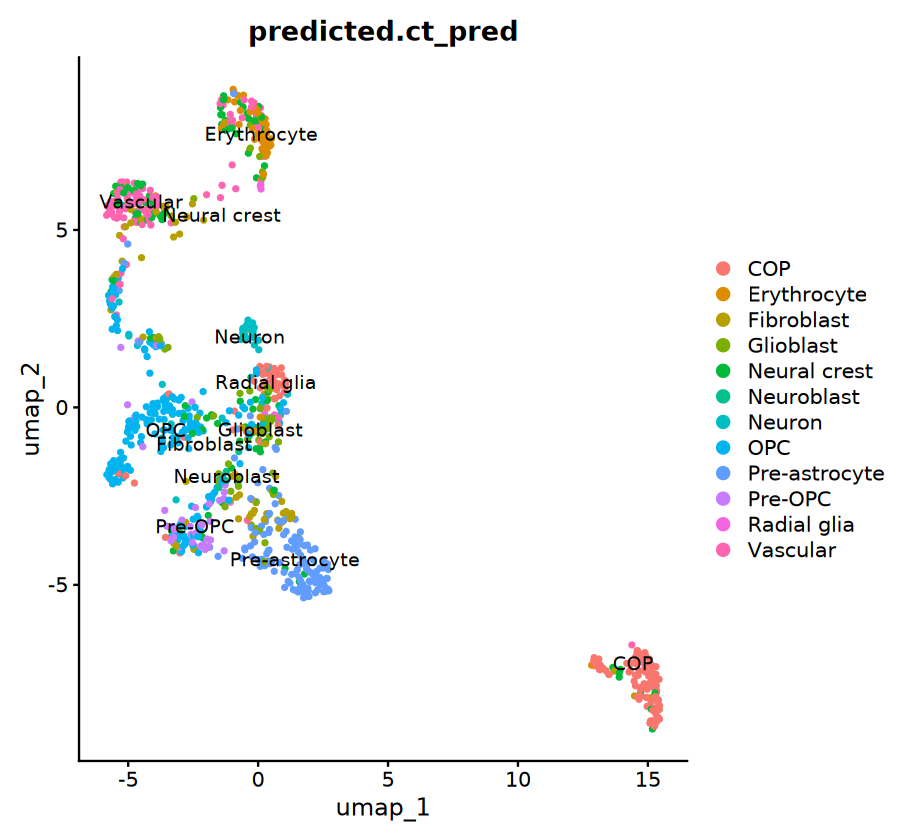

In [59]:
DimPlot(obj.atac, group.by = "predicted.ct_pred", reduction = "umap", label = TRUE)

Warning message:
"Removed 6 rows containing missing values or values outside the scale range (`geom_segment()`)."


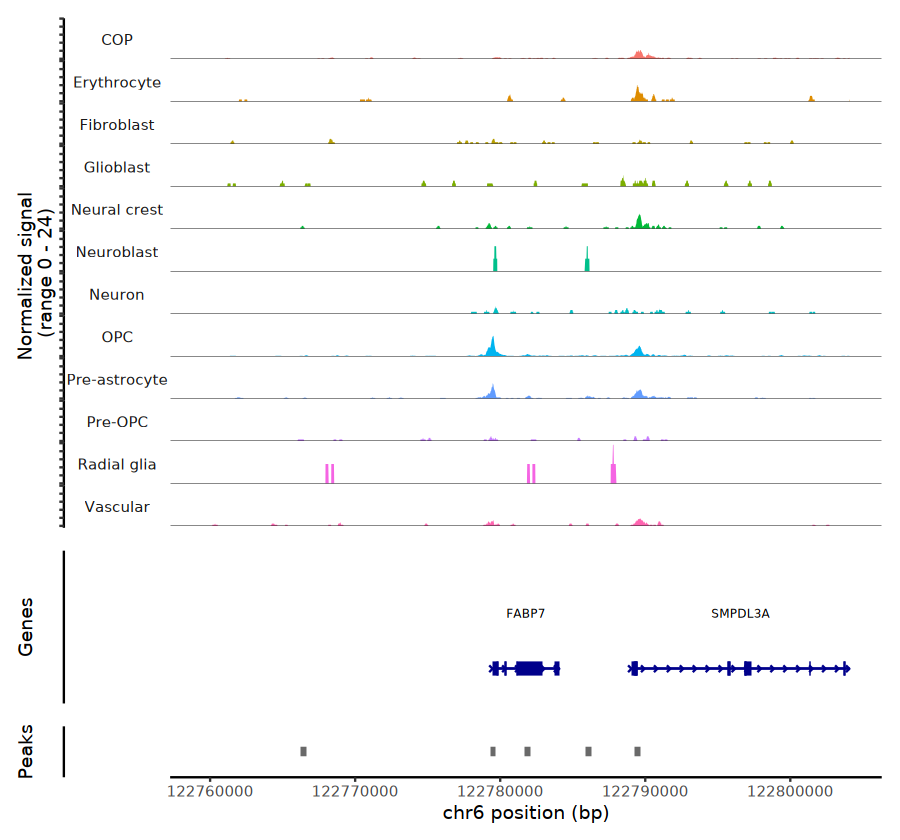

In [60]:
CoveragePlot(
  obj.atac, region  = "FABP7", group.by = "predicted.ct_pred", window = 200,
   extend.upstream = 20000,
  extend.downstream = 20000)

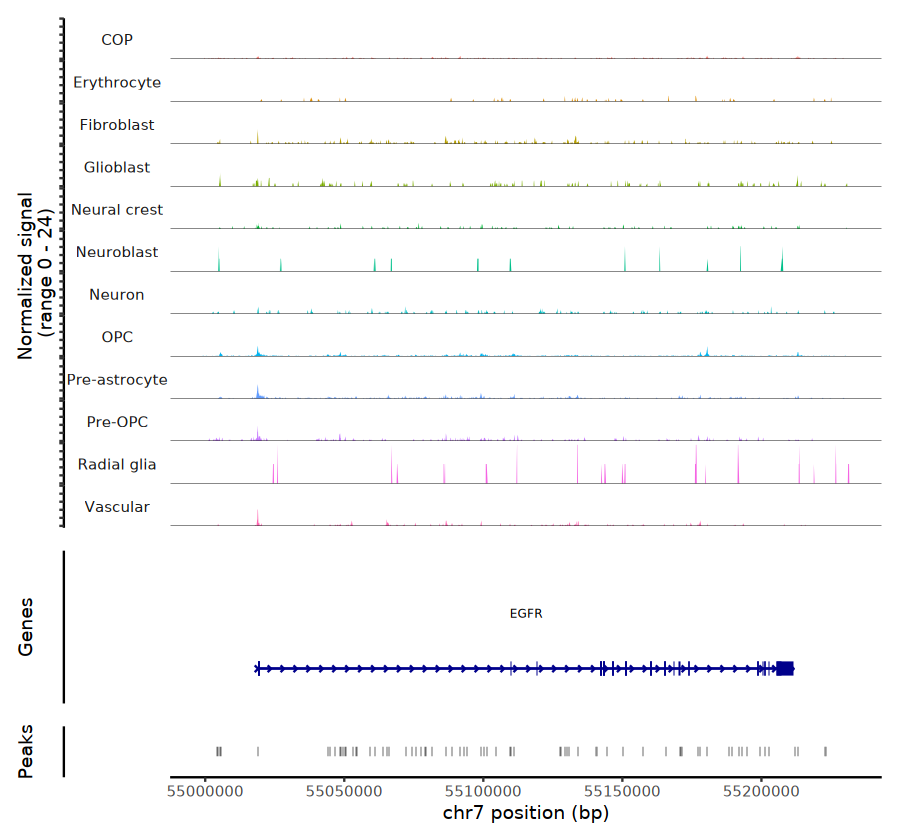

In [61]:
CoveragePlot(
  obj.atac, region  = "EGFR", group.by = "predicted.ct_pred", window = 200,
   extend.upstream = 20000,
  extend.downstream = 20000)